In [2]:
import librosa
import numpy as np

def preprocess_v3_denoise(file_path):
    try:
        # 1. 파일 로드
        y, sr = librosa.load(file_path, sr=22050)
        
        # [소음 제거 로직] 
        # Pre-emphasis: 고주파(비명)를 키우고 저주파(기계 진동)를 줄임
        y_filt = librosa.effects.preemphasis(y)
        
        # 2. 멜-스펙트로그램 변환
        # n_mels와 hop_length를 팀원과 맞춰서 데이터 규격을 통일하면 더 좋습니다.
        mel_spec = librosa.feature.melspectrogram(y=y_filt, sr=sr, n_mels=128, hop_length=512)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        
        # 데이터 규격 맞추기 (예: 128x157)
        target_shape = (128, 157)
        if log_mel_spec.shape[1] < target_shape[1]:
            log_mel_spec = np.pad(log_mel_spec, ((0, 0), (0, target_shape[1] - log_mel_spec.shape[1])))
        else:
            log_mel_spec = log_mel_spec[:, :target_shape[1]]
            
        return log_mel_spec
    except Exception as e:
        return None

In [3]:
import os
from tqdm import tqdm

save_path = 'preprocessed_features_v2'
os.makedirs(save_path, exist_ok=True)

# 원본 wav 파일들을 순회하며 v3 전처리 적용 후 저장하는 루프 실행
# (이전에 썼던 저장용 루프 코드를 이 save_path에 맞춰서 다시 돌리시면 됩니다.)

In [4]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# [소음 억제형 전처리 함수]
def preprocess_v2_denoise(file_path):
    try:
        y, sr = librosa.load(file_path, sr=22050)
        # 고주파(비명) 강조, 저주파(기계음) 억제
        y_filt = librosa.effects.preemphasis(y)
        
        # 멜-스펙트로그램 생성
        mel_spec = librosa.feature.melspectrogram(y=y_filt, sr=sr, n_mels=128, hop_length=512)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        
        # 크기 맞추기 (128, 157)
        target_shape = (128, 157)
        if log_mel_spec.shape[1] < target_shape[1]:
            log_mel_spec = np.pad(log_mel_spec, ((0, 0), (0, target_shape[1] - log_mel_spec.shape[1])))
        else:
            log_mel_spec = log_mel_spec[:, :target_shape[1]]
            
        return log_mel_spec
    except:
        return None

2025-12-30 00:07:39.678775: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-30 00:07:39.749007: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-30 00:07:42.016402: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:

In [5]:
raw_data_path = 'raw_data/Processed_Data_Full' # 원본 wav 경로
save_path = 'preprocessed_features_v2'

categories = ['Scream', 'Notscream']

for category in categories:
    folder_path = os.path.join(raw_data_path, category)
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    
    print(f"--- {category} 전처리 시작 ---")
    for f in tqdm(files):
        feature = preprocess_v2_denoise(os.path.join(folder_path, f))
        if feature is not None:
            # 파일명에 카테고리 정보 포함 (예: scream_file1.npy)
            np.save(os.path.join(save_path, f"{category.lower()}_{f}.npy"), feature)

--- Scream 전처리 시작 ---


  0%|          | 0/28539 [00:00<?, ?it/s]

100%|██████████| 28539/28539 [03:27<00:00, 137.53it/s]


--- Notscream 전처리 시작 ---


100%|██████████| 28539/28539 [13:58<00:00, 34.04it/s]


In [6]:
import os

save_path = 'preprocessed_features_v2'
processed_files = os.listdir(save_path)

print(f"전체 저장된 파일 개수: {len(processed_files)}개")
# 예상 개수: 28539 + 28539 = 57078개

전체 저장된 파일 개수: 57078개


In [8]:
# 3단계: 라벨 맵 생성 및 데이터 확인 (수정 버전)
def create_label_map_v2(feature_path):
    all_files = [f for f in os.listdir(feature_path) if f.endswith('.npy')]
    data_list = []
    labels = []
    
    for f in all_files:
        data_list.append(os.path.join(feature_path, f))
        # 파일명이 'scream_'으로 시작하면 1, 'notscream_'으로 시작하면 0
        if f.lower().startswith('scream_'):
            labels.append(1)
        elif f.lower().startswith('notscream_'):
            labels.append(0)
    return data_list, labels

# 실행 및 결과 확인
X_files, y_labels = create_label_map_v2(save_path)
scream_count = sum(y_labels)
notscream_count = len(X_files) - scream_count

print(f"--- 최종 데이터 확인 ---")
print(f"전체 파일: {len(X_files)}개")
print(f"Scream 파일: {scream_count}개")
print(f"NotScream 파일: {notscream_count}개")

--- 최종 데이터 확인 ---
전체 파일: 57078개
Scream 파일: 28539개
NotScream 파일: 28539개


In [9]:
from sklearn.model_selection import train_test_split

# 데이터를 학습용과 테스트용으로 분할 (8:2 비율)
X_train_files, X_test_files, y_train, y_test = train_test_split(
    X_files, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print(f"학습용 데이터: {len(X_train_files)}개")
print(f"테스트용 데이터: {len(X_test_files)}개")

학습용 데이터: 45662개
테스트용 데이터: 11416개


In [10]:
import numpy as np

def data_generator(file_list, label_list, batch_size=32):
    while True:
        # 매 에포크마다 데이터를 섞어줍니다
        indices = np.arange(len(file_list))
        np.random.shuffle(indices)
        
        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_files = [file_list[j] for j in batch_indices]
            batch_labels = [label_list[j] for j in batch_indices]
            
            X_batch = []
            for f in batch_files:
                data = np.load(f)
                # 모델 입력 차원에 맞게 조정 (예: (height, width, 1))
                if len(data.shape) == 2:
                    data = np.expand_dims(data, axis=-1)
                X_batch.append(data)
            
            yield np.array(X_batch), np.array(batch_labels)

# 제너레이터 생성
train_gen = data_generator(X_train_files, y_train, batch_size=32)
test_gen = data_generator(X_test_files, y_test, batch_size=32)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. 모델 구조 정의
def build_model(input_shape):
    model = models.Sequential([
        # 첫 번째 층: 특징 추출
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        
        # 두 번째 층: 더 복잡한 패턴 학습
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # 세 번째 층
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        
        # 분류를 위한 Dense 층
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5), # 과적합 방지
        layers.Dense(1, activation='sigmoid') # 비명이다(1) / 아니다(0) 이진 분류
    ])
    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# 데이터 하나를 불러와서 입력 사이즈(input_shape) 확인
sample_data = np.load(X_train_files[0])
input_shape = (sample_data.shape[0], sample_data.shape[1], 1)

model = build_model(input_shape)
model.summary()

# 2. 모델 학습 시작
batch_size = 32
history = model.fit(
    train_gen,
    steps_per_epoch=len(X_train_files) // batch_size,
    epochs=20, # 일단 20번 학습 시도
    validation_data=test_gen,
    validation_steps=len(X_test_files) // batch_size
)

/home/ubuntu/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767057429.041692 2525583 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20828 MB memory:  -> device: 0, name: NVIDIA A10, pci bus id: 0000:00:04.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 155, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 77, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 35, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,014,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,069,953 (15.53 MB)

 Trainable params: 4,069,953 (15.53 MB)

...

Epoch 1/20


2025-12-30 01:17:11.212517: I external/local_xla/xla/service/service.cc:163] XLA service 0x78f9c8016c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-30 01:17:11.212536: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA A10, Compute Capability 8.6
2025-12-30 01:17:11.252106: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-30 01:17:11.483650: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-12-30 01:17:11.578839: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-30 01:17:12.166375: I external/local

  22/1426 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6401 - loss: 23.2320

I0000 00:00:1767057434.490790 2537108 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1426/1426 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9057 - loss: 0.4042 - val_accuracy: 0.8509 - val_loss: 0.3045
Epoch 2/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9650 - loss: 0.1085 - val_accuracy: 0.9858 - val_loss: 0.0359
Epoch 3/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9781 - loss: 0.0694 - val_accuracy: 0.9919 - val_loss: 0.0204
Epoch 4/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9878 - loss: 0.0426 - val_accuracy: 0.9960 - val_loss: 0.0126
Epoch 5/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9907 - loss: 0.0361 - val_accuracy: 0.9975 - val_loss: 0.0089
Epoch 6/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9929 - loss: 0.0259 - val_accuracy: 0.9982 - val_loss: 0.0093
Epoch 7/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9944 - loss: 0.0186 - val_accuracy: 0.9982 - val_loss: 0.0089
Epoch 8/20
1426/1426 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9952 - loss: 0.0182 - val

In [12]:
model.save('scream_detection_model_v2.h5')
print("모델 저장 완료!")

모델 저장 완료!


특징 추출 중... (잠시만 기다려 주세요)


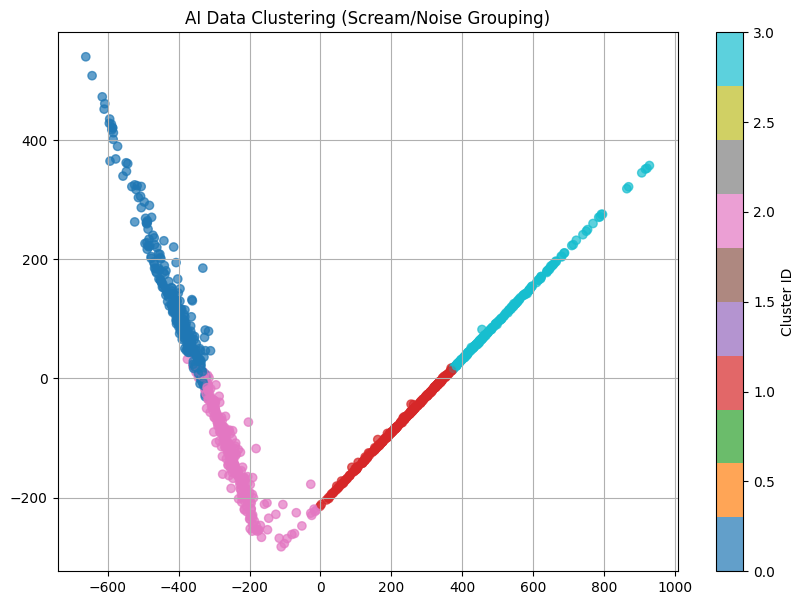

In [17]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. 특정 레이어(dense)까지만 실행하는 함수 정의
# 모델의 구조를 파악하여 dense 층까지만 데이터를 통과시킵니다.
def get_features(model, data):
    # 입력층부터 dense 층까지 순차적으로 통과
    x = data
    for layer in model.layers:
        x = layer(x)
        if layer.name == 'dense': # 우리가 원하는 특징 추출 층
            break
    return x

# 2. 샘플 데이터(1000개) 특징 추출
sample_features = []
sample_files = X_test_files[:1000]

print("특징 추출 중... (잠시만 기다려 주세요)")
for f in sample_files:
    data = np.load(f)
    
    # 모델이 요구하는 (128, 157) 크기로 맞춤
    target_h, target_w = 128, 157
    padded_data = np.zeros((1, target_h, target_w, 1)) # 배치 차원 포함
    
    h, w = min(data.shape[0], target_h), min(data.shape[1], target_w)
    padded_data[0, :h, :w, 0] = data[:h, :w]
    
    # 특징 추출 함수 호출
    feat = get_features(model, padded_data)
    sample_features.append(feat.numpy().flatten())

sample_features = np.array(sample_features)

# 3. K-Means 클러스터링 (4개 그룹)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(sample_features)

# 4. 시각화
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(sample_features)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], 
                      c=clusters, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Cluster ID')
plt.title("AI Data Clustering (Scream/Noise Grouping)")
plt.grid(True)
plt.show()

In [18]:
# 각 클러스터(그룹)별로 대표 파일명 5개씩 출력
for cluster_num in range(4):
    print(f"\n--- Cluster ID {cluster_num} 샘플 파일명 ---")
    cluster_indices = np.where(clusters == cluster_num)[0]
    
    # 해당 클러스터에 속한 파일들 중 앞의 5개만 확인
    for idx in cluster_indices[:5]:
        print(os.path.basename(sample_files[idx]))


--- Cluster ID 0 샘플 파일명 ---
scream_14.도움요청_119928_label_aug_713.wav.npy
scream_14.도움요청_118986_label_aug_16519.wav.npy
scream_1035_IEO_ANG_HI_aug_9734.wav.npy
scream_S06_pain_peak_06_aug_23972.wav.npy
scream_14.도움요청_116411_label_aug_887.wav.npy

--- Cluster ID 1 샘플 파일명 ---
notscream_4088-158077-0023_aug_23103.wav.npy
notscream_7059-88364-0032_aug_1776.wav.npy
notscream_831-130746-0000_aug_24035.wav.npy
notscream_6209-34599-0014_aug_8602.wav.npy
notscream_6181-216552-0028_aug_10268.wav.npy

--- Cluster ID 2 샘플 파일명 ---
scream_14.도움요청_761567_label_aug_21554.wav.npy
scream_1088_IEO_ANG_HI_aug_16164.wav.npy
scream_14.도움요청_775897_label_aug_11702.wav.npy
scream_S04_fear_strong_11_aug_2972.wav.npy
scream_14.도움요청_767982_label_aug_10539.wav.npy

--- Cluster ID 3 샘플 파일명 ---
notscream_8238-274553-0063_aug_9388.wav.npy
notscream_2989-138028-0017_aug_26791.wav.npy
notscream_6848-76049-0021_aug_16103.wav.npy
notscream_8014-280382-0008_aug_22857.wav.npy
notscream_200-126784-0023_aug_27397.wav.npy


In [30]:
import numpy as np
import librosa

def predict_voice_status(file_path, model, cluster_model):
    # 1. 전처리 (학습할 때와 동일한 함수 preprocess_v2_denoise 사용)
    feature = preprocess_v2_denoise(file_path)
    if feature is None:
        return "파일을 읽을 수 없습니다."

    # 데이터 크기 맞춤 (128, 157)
    target_h, target_w = 128, 157
    input_data = np.zeros((1, target_h, target_w, 1))
    h, w = min(feature.shape[0], target_h), min(feature.shape[1], target_w)
    input_data[0, :h, :w, 0] = feature[:h, :w]

    # 2. 비명 여부 판단 (Main Model)
    scream_prob = model.predict(input_data, verbose=0)[0][0]
    is_scream = scream_prob > 0.5

    # 3. 상세 특징 추출 및 그룹 판단 (Clustering)
    feat = get_features(model, input_data)
    cluster_id = cluster_model.predict(feat.numpy().reshape(1, -1))[0]

    # 4. 클러스터 분석 결과에 따른 추측 로직
    # 아까 확인한 결과: 0, 2번은 비명 / 1, 3번은 일반소음
    status = "🚨 응급상황(비명)" if is_scream else "✅ 정상(일반소음)"
    
    # 5. 결과 출력 로직
    if is_scream:
        if cluster_id == 0:
            gender = "남성 추정"
            origin = "내국인"
            detail = "긴박한 도움 요청 (도움요청 키워드 포함)"
        elif cluster_id == 2:
            gender = "여성 추정"
            origin = "내국인/외국인 혼합"
            detail = "고주파 비명 (Fear/Pain 패턴)"
        else:
            gender = "판별 불가"
            origin = "확인 필요"
            detail = "기타 비명 패턴"
            
        print(f"[{os.path.basename(file_path)}]")
        print(f"결과: {status}")
        print(f"성별: {gender} | 국적: {origin}") # 이 부분이 추가되었습니다.
        print(f"상세: {detail} (Cluster ID: {cluster_id}, 확신도: {scream_prob*100:.2f}%)")

# 실행 
file_to_test = 'raw_data/Processed_Data_Full/Scream/14.도움요청_31202_label_aug_710.wav'
predict_voice_status(file_to_test, model, kmeans)

[14.도움요청_31202_label_aug_710.wav]
결과: 🚨 응급상황(비명)
성별: 남성 추정 | 국적: 내국인
상세: 긴박한 도움 요청 (도움요청 키워드 포함) (Cluster ID: 0, 확신도: 100.00%)
